# Spheroid Segmentation Inference - New Data
## Process Control and Treated Images

**Important:** Model was trained on **512×512** resized images, so predictions come out as 512×512.  
We resize predictions back to **each image's original dimensions** for accurate analysis.

**Prediction values:** 0 (background) and 1 (spheroid) - binary segmentation.

## 1. Configuration
⚠️ **UPDATE THESE PATHS BEFORE RUNNING!**

In [51]:
# ============================================================================
# CONFIGURATION - UPDATE THESE PATHS!
# ============================================================================

# Model settings
MODEL_NAME = 'unet_resnet34_spheroid_boundary'  # Your saved model name (without .pth extension)
MODEL_PATH = './models'  # Directory where your .pth file is located
ENCODER = 'resnet34'  # Encoder used during training

# Data paths
DATA_DIR = './controlTreatedData'  # Directory with Control and Treated folders
OUTPUT_DIR = './inference_results'  # Where to save results
TRAINING_DATA_PATH = './data/organized/images/train'  # Any path with images (for dataloader init)

# Model parameters (MUST match training!)
IMG_SIZE = 512  # Image size used during training (512×512)
BATCH_SIZE = 1  # Keep at 1 for inference

# Visualization settings
OVERLAY_ALPHA = 0.3  # Transparency for overlays (0-1)
CONTOUR_COLOR = (255, 0, 0)  # BGR: Red for predictions

## 2. Import Libraries

In [52]:
# ============================================================================
# PREPROCESSING & POST-PROCESSING SETTINGS - ADJUST THESE!
# ============================================================================

# Preprocessing (enhance dark images)
APPLY_PREPROCESSING = True  # Set False to disable

# CLAHE - Contrast enhancement
APPLY_CLAHE = True
CLAHE_CLIP_LIMIT = 2.5  # 🔧 Try 2.0-4.0 (higher = more contrast)
CLAHE_TILE_SIZE = 8

# Brightness boost
APPLY_BRIGHTNESS = True
BRIGHTNESS_FACTOR = 1.3  # 🔧 Try 1.2-1.6 (higher = brighter)

# Post-processing (clean up masks)
APPLY_POSTPROCESSING = True

# Morphology
APPLY_MORPHOLOGY = True
MORPH_KERNEL_SIZE = 5  # 🔧 Try 3, 5, or 7

# Size filtering
MIN_OBJECT_SIZE = 250000  # 🔧 Increase to remove more noise

print("✅ Preprocessing configured")
print(f"   CLAHE: {CLAHE_CLIP_LIMIT}, Brightness: {BRIGHTNESS_FACTOR}x")

✅ Preprocessing configured
   CLAHE: 2.5, Brightness: 1.3x


In [53]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fastai.vision.core import PILImage, PILMask
from fastai.vision.all import *
from fastai.data.block import DataBlock
from fastai.data.transforms import FuncSplitter, Normalize, get_image_files
from fastai.metrics import Dice
from fastai.vision.data import ImageBlock, MaskBlock, imagenet_stats
from fastai.vision.augment import Resize, ResizeMethod
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ENVIRONMENT CHECK")
print("="*70)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️  Running on CPU")
print("="*70)

ENVIRONMENT CHECK
PyTorch: 2.4.1
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.00 GB


## 3. Import Custom Modules
⚠️ Make sure `boundary_losses.py` and `boundary_metrics.py` are in the same directory!

In [54]:
try:
    from boundary_losses import CombinedBoundaryLoss
    from boundary_metrics import BoundaryIoU, BoundaryF1, AreaAccuracy, accuracy_spheroid
    print("✅ Custom modules imported successfully!")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    print("\n⚠️  Make sure boundary_losses.py and boundary_metrics.py are in the same directory.")
    print("    Or comment out this cell if you don't need custom losses for inference.")
    raise

✅ Custom modules imported successfully!


## 4. Helper Functions for DataLoader

In [55]:
# These are needed to recreate the dataloader structure
CODES = np.array(['Background', 'Spheroid'])

def get_mask_dummy(img_path):
    """Dummy function - not used for inference but needed for dataloader creation."""
    return img_path

def train_val_splitter_dummy(path):
    """All data treated as validation for inference."""
    return False

def get_dataloader(img_size, bs=1):
    """Create dataloader matching training configuration."""
    batch_tfms = [Normalize.from_stats(*imagenet_stats)]
    
    dblock = DataBlock(
        blocks=(ImageBlock, MaskBlock(codes=CODES)),
        get_items=get_image_files,
        splitter=FuncSplitter(train_val_splitter_dummy),
        get_y=get_mask_dummy,
        item_tfms=Resize(img_size, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros),
        batch_tfms=batch_tfms
    )
    
    # Use training data path or any valid path for initialization
    path = Path(TRAINING_DATA_PATH)
    if not path.exists():
        print(f"⚠️  Warning: {path} not found. Trying alternative paths...")
        alternatives = [
            Path('./data/organized/images/val'),
            Path('./data/organized/images/test'),
            Path(DATA_DIR) / 'Control',
        ]
        for alt in alternatives:
            if alt.exists():
                path = alt
                print(f"✅ Using: {path}")
                break
    
    dls = dblock.dataloaders(path, bs=bs)
    return dls

print("✅ Helper functions defined")

✅ Helper functions defined


In [56]:
# ============================================================================
# PREPROCESSING & POST-PROCESSING FUNCTIONS
# ============================================================================

def preprocess_image(image):
    """Enhance image contrast and brightness."""
    if not APPLY_PREPROCESSING:
        return image
    
    img = image.copy()
    
    # CLAHE
    if APPLY_CLAHE:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, 
                                tileGridSize=(CLAHE_TILE_SIZE, CLAHE_TILE_SIZE))
        gray_enhanced = clahe.apply(gray)
        img = cv2.cvtColor(gray_enhanced, cv2.COLOR_GRAY2BGR) if len(image.shape) == 3 else gray_enhanced
    
    # Brightness
    if APPLY_BRIGHTNESS:
        img = (img.astype(np.float32) * BRIGHTNESS_FACTOR).clip(0, 255).astype(np.uint8)
    
    return img


def postprocess_mask(mask):
    """Clean up segmentation mask."""
    if not APPLY_POSTPROCESSING:
        return mask
    
    mask_clean = mask.copy().astype(np.uint8)
    
    # Morphology
    if APPLY_MORPHOLOGY:
        kernel = np.ones((MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE), np.uint8)
        mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)
        mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)
    
    # Size filtering
    if MIN_OBJECT_SIZE > 0:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_clean, connectivity=8)
        mask_filtered = np.zeros_like(mask_clean)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= MIN_OBJECT_SIZE:
                mask_filtered[labels == i] = 1
        mask_clean = mask_filtered
    
    return mask_clean

print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


## 5. Load Model from .pth File
This loads your model weights that were saved with `learn.save()`

In [57]:
print("\n" + "="*70)
print("LOADING MODEL")
print("="*70)

# Step 1: Create dataloader
print("\n1️⃣ Creating dataloader...")
try:
    dls = get_dataloader(img_size=IMG_SIZE, bs=BATCH_SIZE)
    print("   ✅ Dataloader created")
except Exception as e:
    print(f"   ❌ Error creating dataloader: {e}")
    print("   Please check TRAINING_DATA_PATH in configuration.")
    raise

# Step 2: Create learner with same architecture as training
print("\n2️⃣ Creating learner with architecture...")
try:
    learn = unet_learner(
        dls,
        eval(ENCODER),  # resnet34, resnet50, etc.
        loss_func=CombinedBoundaryLoss(),
        metrics=[Dice(), accuracy_spheroid]
    )
    print(f"   ✅ U-Net learner created with {ENCODER} encoder")
except Exception as e:
    print(f"   ❌ Error creating learner: {e}")
    raise

# Step 3: Load the saved weights
print("\n3️⃣ Loading model weights...")
model_file = Path(MODEL_PATH) / f"{MODEL_NAME}.pth"
print(f"   Loading from: {model_file}")

try:
    if not model_file.exists():
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    learn.load(MODEL_NAME, device='cpu' if not torch.cuda.is_available() else None)
    print("   ✅ Model weights loaded successfully!")
    
    # Verify GPU
    if torch.cuda.is_available():
        learn.model = learn.model.cuda()
        print(f"   ✅ Model moved to GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("   ⚠️  Model running on CPU")
        
except Exception as e:
    print(f"   ❌ Error loading model weights: {e}")
    print("\n   Troubleshooting:")
    print("   - Check MODEL_NAME is correct (without .pth extension)")
    print("   - Check MODEL_PATH points to the directory with your .pth file")
    print("   - Verify ENCODER matches what you used during training")
    raise

print("\n" + "="*70)
print("MODEL LOADED SUCCESSFULLY!")
print("="*70)


LOADING MODEL

1️⃣ Creating dataloader...
   ✅ Dataloader created

2️⃣ Creating learner with architecture...
   ✅ U-Net learner created with resnet34 encoder

3️⃣ Loading model weights...
   Loading from: models\unet_resnet34_spheroid_boundary.pth
   ✅ Model weights loaded successfully!
   ✅ Model moved to GPU: NVIDIA GeForce RTX 3050 Laptop GPU

MODEL LOADED SUCCESSFULLY!


## 6. Test Model on Single Image
Quick test to verify the model works before processing all images

🧪 Testing on: B_0002.jpg

Original size: 3032×3032


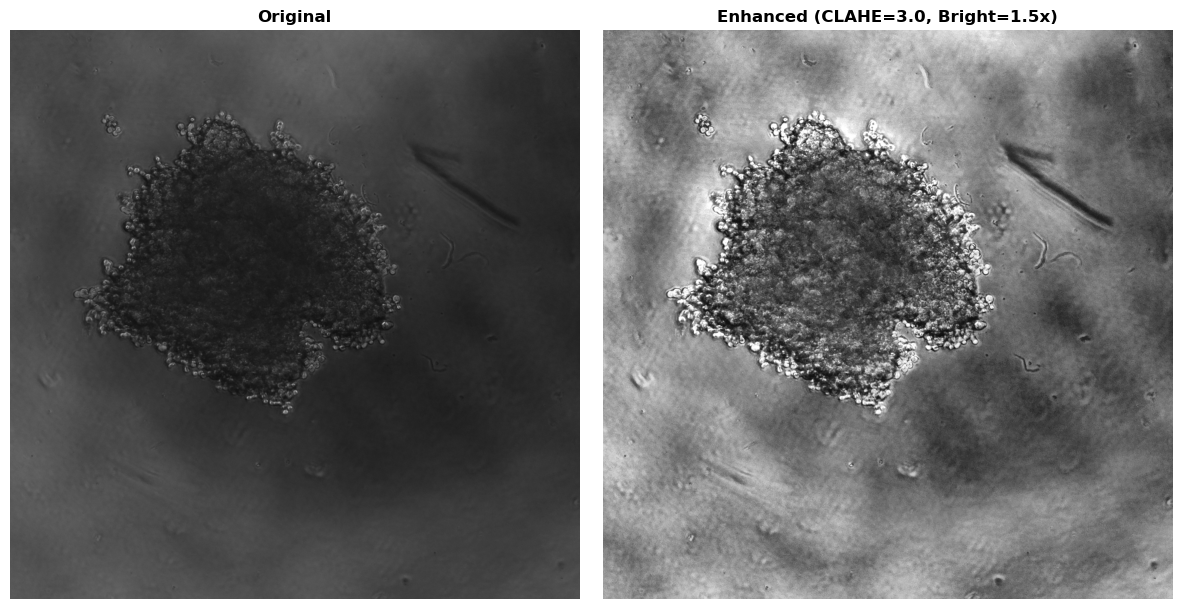


Prediction: 512×512 → 3032×3032
Before cleanup: 1550791 pixels
After cleanup:  1438842 pixels
Removed:        111949 pixels



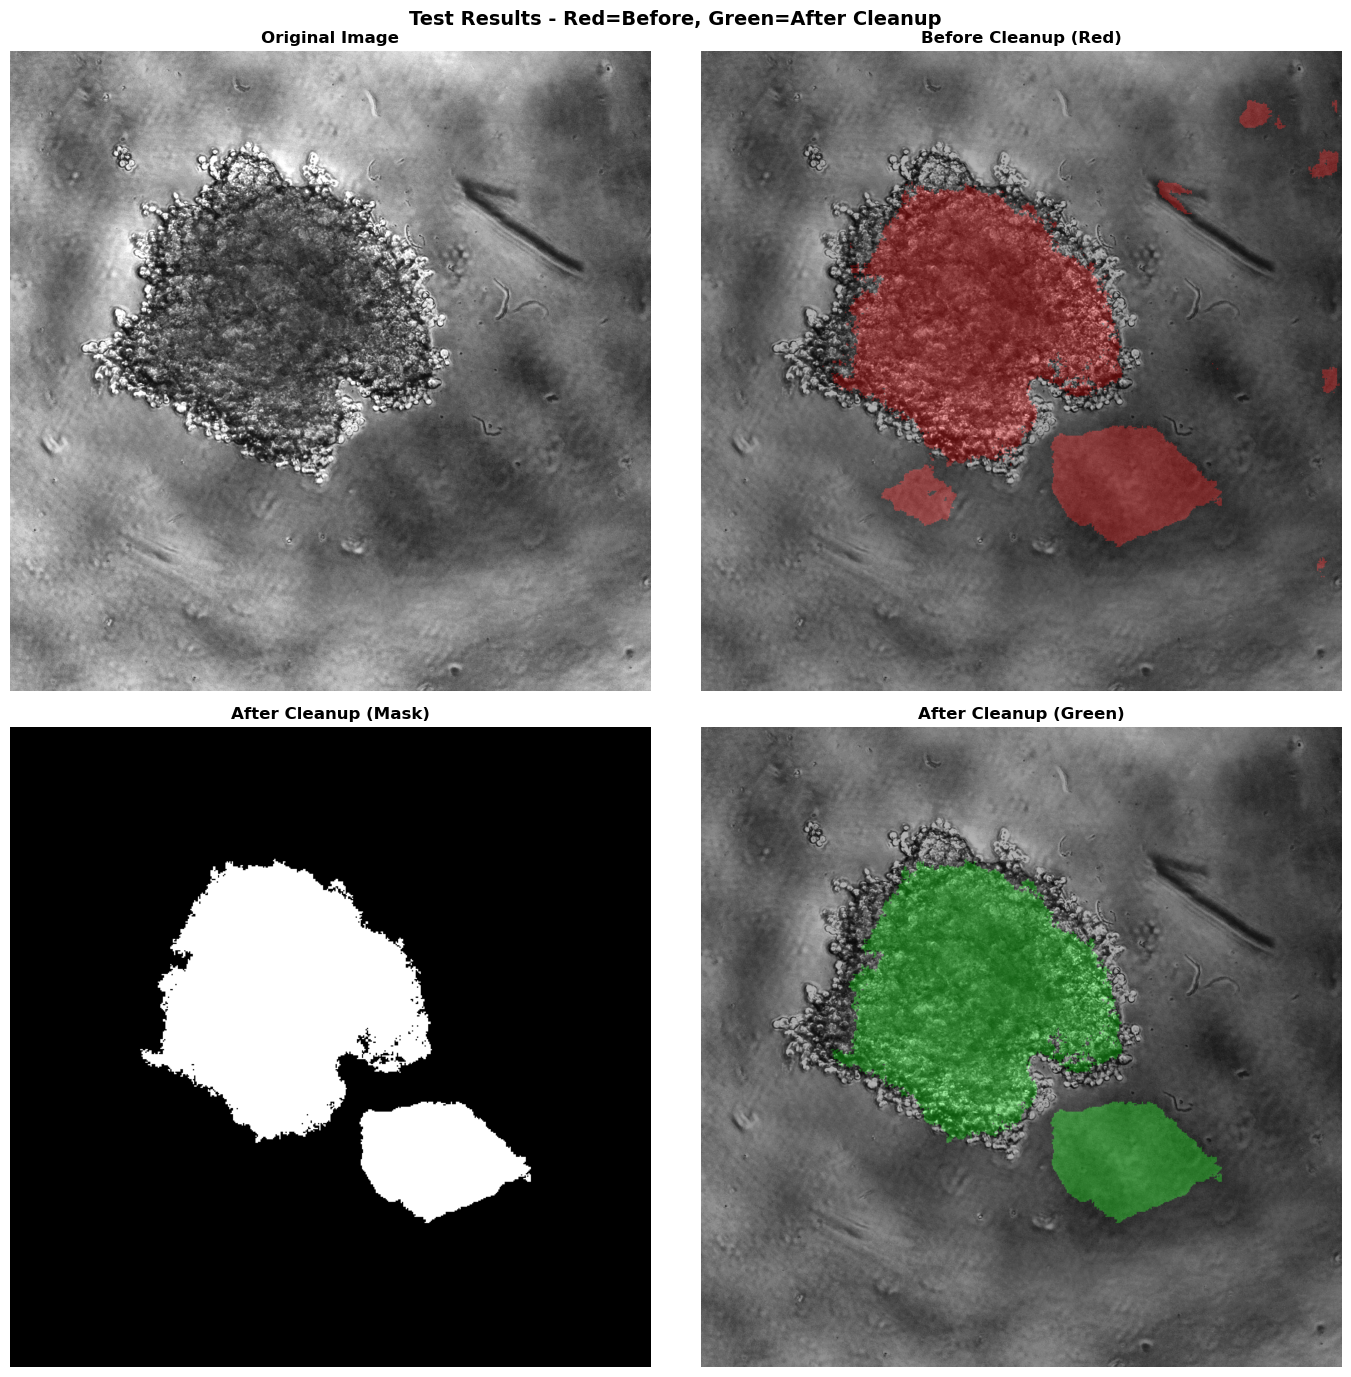

✅ Test complete! Compare Red vs Green overlay.
   Still bleeding? → INCREASE CLAHE_CLIP_LIMIT or MIN_OBJECT_SIZE
   Too restrictive? → DECREASE those values
   Change values in config cell and re-run this cell to test!


In [58]:
# Find first available test image
test_groups = ['Control', 'Treated']
test_img_path = None

CLAHE_CLIP_LIMIT = 3.0
BRIGHTNESS_FACTOR = 1.5

for group in test_groups:
    test_dir = Path(DATA_DIR) / group
    if test_dir.exists():
        images = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.png'))
        if images:
            test_img_path = images[0]
            break

if test_img_path:
    print(f"🧪 Testing on: {test_img_path.name}\n")
    
    # Load original
    img_original = cv2.imread(str(test_img_path))
    if img_original is None:
        raise ValueError(f"Could not load: {test_img_path}")
    if len(img_original.shape) == 2:
        img_original = cv2.cvtColor(img_original, cv2.COLOR_GRAY2RGB)
    original_h, original_w = img_original.shape[:2]
    print(f"Original size: {original_w}×{original_h}")
    
    # Apply preprocessing
    img_preprocessed = preprocess_image(img_original)
    
    # Show comparison if preprocessing is enabled
    if APPLY_PREPROCESSING:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(img_preprocessed, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Enhanced (CLAHE={CLAHE_CLIP_LIMIT}, Bright={BRIGHTNESS_FACTOR}x)', 
                         fontsize=12, fontweight='bold')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
    
    # Save preprocessed temporarily
    temp_path = Path('temp_prep.png')
    cv2.imwrite(str(temp_path), img_preprocessed)
    
    # Predict
    test_img = PILImage.create(temp_path)
    pred_class, pred_idx, probs = learn.predict(test_img)
    pred_mask = np.array(pred_class)
    temp_path.unlink()
    
    # Resize to original
    pred_mask_resized = cv2.resize(
        pred_mask.astype(np.uint8),
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )
    
    # Apply post-processing
    pred_mask_cleaned = postprocess_mask(pred_mask_resized)
    
    print(f"\nPrediction: {pred_mask.shape[1]}×{pred_mask.shape[0]} → {pred_mask_resized.shape[1]}×{pred_mask_resized.shape[0]}")
    print(f"Before cleanup: {np.sum(pred_mask_resized > 0)} pixels")
    print(f"After cleanup:  {np.sum(pred_mask_cleaned > 0)} pixels")
    print(f"Removed:        {np.sum(pred_mask_resized > 0) - np.sum(pred_mask_cleaned > 0)} pixels\n")
    
    # Visualize before/after
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    img_rgb = cv2.cvtColor(img_preprocessed, cv2.COLOR_BGR2RGB)  # Use enhanced instead
    
    # Original
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Before cleanup (Red)
    overlay_before = np.zeros_like(img_rgb)
    overlay_before[pred_mask_resized > 0] = [255, 0, 0]
    blended_before = cv2.addWeighted(img_rgb, 0.7, overlay_before, 0.3, 0)
    axes[0, 1].imshow(blended_before)
    axes[0, 1].set_title('Before Cleanup (Red)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Cleaned mask
    axes[1, 0].imshow(pred_mask_cleaned, cmap='gray')
    axes[1, 0].set_title('After Cleanup (Mask)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # After cleanup (Green)
    overlay_after = np.zeros_like(img_rgb)
    overlay_after[pred_mask_cleaned > 0] = [0, 255, 0]
    blended_after = cv2.addWeighted(img_rgb, 0.7, overlay_after, 0.3, 0)
    axes[1, 1].imshow(blended_after)
    axes[1, 1].set_title('After Cleanup (Green)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.suptitle('Test Results - Red=Before, Green=After Cleanup', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("="*70)
    print("✅ Test complete! Compare Red vs Green overlay.")
    print("   Still bleeding? → INCREASE CLAHE_CLIP_LIMIT or MIN_OBJECT_SIZE")
    print("   Too restrictive? → DECREASE those values")
    print("   Change values in config cell and re-run this cell to test!")
    print("="*70)
else:
    print("⚠️  No test images found")

## 7. Create Output Directories

In [59]:
output_base = Path(OUTPUT_DIR)
output_base.mkdir(exist_ok=True)

# Create subdirectories
subdirs = ['overlays', 'contours', 'grids', 'masks', 'predictions']
for subdir in subdirs:
    for group in ['Control', 'Treated']:
        (output_base / subdir / group).mkdir(parents=True, exist_ok=True)

print(f"✅ Created output directories in: {output_base}")
print(f"\nDirectory structure:")
for subdir in subdirs:
    print(f"  ├── {subdir}/")
    print(f"  │   ├── Control/")
    print(f"  │   └── Treated/")

✅ Created output directories in: inference_results

Directory structure:
  ├── overlays/
  │   ├── Control/
  │   └── Treated/
  ├── contours/
  │   ├── Control/
  │   └── Treated/
  ├── grids/
  │   ├── Control/
  │   └── Treated/
  ├── masks/
  │   ├── Control/
  │   └── Treated/
  ├── predictions/
  │   ├── Control/
  │   └── Treated/


## 8. Metric Calculation Functions

In [60]:
def calculate_metrics(mask):
    """Calculate comprehensive spheroid metrics from binary mask."""
    area = np.sum(mask > 0)
    
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    metrics = {
        'area_pixels': area,
        'num_objects': len(contours),
        'perimeter': 0,
        'circularity': 0,
        'equivalent_diameter': 0,
        'bbox_width': 0,
        'bbox_height': 0,
        'aspect_ratio': 0,
        'ellipse_major_axis': 0,
        'ellipse_minor_axis': 0,
        'ellipse_ratio': 0,
    }
    
    if contours:
        # Get largest contour (main spheroid)
        largest = max(contours, key=cv2.contourArea)
        
        # Perimeter
        perimeter = cv2.arcLength(largest, True)
        metrics['perimeter'] = perimeter
        
        # Circularity: 4π * area / perimeter² (1.0 = perfect circle)
        if perimeter > 0:
            metrics['circularity'] = (4 * np.pi * cv2.contourArea(largest)) / (perimeter ** 2)
        
        # Equivalent diameter (diameter of circle with same area)
        metrics['equivalent_diameter'] = np.sqrt(4 * area / np.pi)
        
        # Bounding box
        x, y, w, h = cv2.boundingRect(largest)
        metrics['bbox_width'] = w
        metrics['bbox_height'] = h
        metrics['aspect_ratio'] = w / h if h > 0 else 0
        
        # Ellipse fitting (if enough points)
        if len(largest) >= 5:
            try:
                ellipse = cv2.fitEllipse(largest)
                (center_x, center_y), (major_axis, minor_axis), angle = ellipse
                metrics['ellipse_major_axis'] = major_axis
                metrics['ellipse_minor_axis'] = minor_axis
                metrics['ellipse_ratio'] = major_axis / minor_axis if minor_axis > 0 else 0
            except:
                pass
    
    return metrics

print("✅ Metric calculation functions defined")

✅ Metric calculation functions defined


## 9. Visualization Functions

In [61]:
def create_visualization_grid(image, pred_mask, metrics):
    """Create 2x2 grid visualization with metrics."""
    # Ensure RGB
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    h, w = image.shape[:2]
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    # Calculate font scale based on image size
    font_scale = max(0.5, min(w, h) / 1000)
    thickness = max(1, int(font_scale * 2))
    
    # 1. Original
    img_original = image.copy()
    cv2.putText(img_original, 'Original', (10, int(40*font_scale)), 
                font, font_scale, (255, 255, 255), thickness)
    
    # 2. Overlay (red)
    img_overlay = image.copy()
    overlay = np.zeros_like(img_overlay)
    overlay[pred_mask > 0] = CONTOUR_COLOR
    img_overlay = cv2.addWeighted(img_overlay, 1-OVERLAY_ALPHA, overlay, OVERLAY_ALPHA, 0)
    cv2.putText(img_overlay, 'Overlay', (10, int(40*font_scale)), 
                font, font_scale, (255, 255, 255), thickness)
    
    # 3. Contours with metrics
    img_contours = image.copy()
    contours, _ = cv2.findContours(pred_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_contours, contours, -1, CONTOUR_COLOR, max(2, int(3*font_scale)))
    
    # Add metrics text
    cv2.putText(img_contours, f"Contours (n={len(contours)})", 
                (10, int(40*font_scale)), font, font_scale, (255, 255, 255), thickness)
    y_pos = int(70*font_scale)
    line_spacing = int(30*font_scale)
    metric_texts = [
        f"Area: {metrics['area_pixels']:.0f} px",
        f"Diam: {metrics['equivalent_diameter']:.1f} px",
        f"Circ: {metrics['circularity']:.3f}",
        f"AR: {metrics['aspect_ratio']:.2f}"
    ]
    for text in metric_texts:
        cv2.putText(img_contours, text, (10, y_pos), 
                    font, font_scale*0.8, (255, 255, 255), max(1, thickness-1))
        y_pos += line_spacing
    
    # 4. Mask only
    img_mask = np.zeros_like(image)
    img_mask[pred_mask > 0] = CONTOUR_COLOR
    cv2.putText(img_mask, 'Prediction', (10, int(40*font_scale)), 
                font, font_scale, (255, 255, 255), thickness)
    
    # Create grid
    top = np.hstack([img_original, img_overlay])
    bottom = np.hstack([img_contours, img_mask])
    grid = np.vstack([top, bottom])
    
    return grid, img_overlay, img_contours, img_mask

print("✅ Visualization functions defined")

✅ Visualization functions defined


## 10. Run Inference on All Images
⏱️ This may take a few minutes depending on the number of images

In [62]:
data_dir = Path(DATA_DIR)
all_results = []

print("\n" + "="*70)
print("RUNNING INFERENCE")
print("="*70)

learn.model.eval()

for group in ['Control', 'Treated']:
    group_dir = data_dir / group
    
    if not group_dir.exists():
        print(f"\n⚠️  Skipping {group} - directory not found: {group_dir}")
        continue
    
    # Get image files
    image_files = sorted(list(group_dir.glob('*.jpg')) + 
                        list(group_dir.glob('*.png')) + 
                        list(group_dir.glob('*.jpeg')))
    
    if not image_files:
        print(f"\n⚠️  No images found in {group}")
        continue
    
    print(f"\n📂 {group.upper()} GROUP")
    print(f"   Found {len(image_files)} images")
    print(f"   Processing...\n")
    
    with torch.no_grad():
        for img_path in tqdm(image_files, desc=f"  {group}"):
            try:
                # Load original image to get TRUE dimensions
                img_original = cv2.imread(str(img_path))
                if img_original is None:
                    print(f"\n⚠️  Could not load {img_path.name}, skipping...")
                    continue
                
                if len(img_original.shape) == 2:
                    img_original = cv2.cvtColor(img_original, cv2.COLOR_GRAY2RGB)
                original_h, original_w = img_original.shape[:2]
                
                # Apply preprocessing
                img_preprocessed = preprocess_image(img_original)
                temp_path = Path('temp_prep.png')
                cv2.imwrite(str(temp_path), img_preprocessed)
                
                # Run prediction on preprocessed image
                img_pil = PILImage.create(temp_path)
                pred_class, _, _ = learn.predict(img_pil)
                pred_mask = np.array(pred_class)
                temp_path.unlink()
                
                # CRITICAL: Resize prediction back to THIS image's original size
                pred_mask_resized = cv2.resize(
                    pred_mask.astype(np.uint8),
                    (original_w, original_h),
                    interpolation=cv2.INTER_NEAREST
                )
                
                # Apply post-processing cleanup
                pred_mask_resized = postprocess_mask(pred_mask_resized)
                
                # Calculate metrics on full-resolution mask
                metrics = calculate_metrics(pred_mask_resized)
                metrics['filename'] = img_path.name
                metrics['group'] = group
                metrics['original_width'] = original_w
                metrics['original_height'] = original_h
                
                # Create visualizations
                grid, overlay, contours, mask_colored = create_visualization_grid(
                    img_original, pred_mask_resized, metrics
                )
                
                # Save outputs
                filename = img_path.name
                mask_filename = filename.replace('.jpg', '.png').replace('.jpeg', '.png')
                
                cv2.imwrite(str(output_base / 'grids' / group / filename), grid)
                cv2.imwrite(str(output_base / 'overlays' / group / filename), overlay)
                cv2.imwrite(str(output_base / 'contours' / group / filename), contours)
                cv2.imwrite(str(output_base / 'predictions' / group / filename), mask_colored)
                # Save mask as PNG with values 0 or 255
                cv2.imwrite(str(output_base / 'masks' / group / mask_filename), 
                           pred_mask_resized.astype(np.uint8) * 255)
                
                all_results.append(metrics)
                
            except Exception as e:
                print(f"\n❌ Error processing {img_path.name}: {e}")
                import traceback
                traceback.print_exc()
                continue

print(f"\n" + "="*70)
print(f"✅ INFERENCE COMPLETE!")
print(f"="*70)
print(f"Total images processed: {len(all_results)}")
print(f"Output directory: {output_base}")


RUNNING INFERENCE

📂 CONTROL GROUP
   Found 60 images
   Processing...



  Control:   0%|          | 0/60 [00:00<?, ?it/s]

  Control:   2%|▏         | 1/60 [00:02<02:14,  2.28s/it]

  Control:   3%|▎         | 2/60 [00:04<02:00,  2.08s/it]

  Control:   5%|▌         | 3/60 [00:06<01:56,  2.05s/it]

...

  Treated:  95%|█████████▌| 57/60 [00:54<00:02,  1.03it/s]

  Treated:  97%|█████████▋| 58/60 [00:55<00:01,  1.01it/s]

  Treated:  98%|█████████▊| 59/60 [00:56<00:00,  1.01it/s]

  Treated: 100%|██████████| 60/60 [00:57<00:00,  1.04it/s]


✅ INFERENCE COMPLETE!
Total images processed: 120
Output directory: inference_results


## 11. Save Results to CSV

In [63]:
if all_results:
    df = pd.DataFrame(all_results)
    csv_path = output_base / 'segmentation_results.csv'
    df.to_csv(csv_path, index=False)
    
    print(f"✅ Results saved to: {csv_path}")
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    display(df.head())
    
    # Show image size distribution
    print(f"\nImage size distribution:")
    size_counts = df.groupby(['original_width', 'original_height']).size()
    for (w, h), count in size_counts.items():
        print(f"  {int(w)}×{int(h)}: {count} images")
else:
    print("⚠️  No results to save. Please check if images were processed correctly.")

✅ Results saved to: inference_results\segmentation_results.csv

DataFrame shape: (120, 15)
Columns: ['area_pixels', 'num_objects', 'perimeter', 'circularity', 'equivalent_diameter', 'bbox_width', 'bbox_height', 'aspect_ratio', 'ellipse_major_axis', 'ellipse_minor_axis', 'ellipse_ratio', 'filename', 'group', 'original_width', 'original_height']

First few rows:


,area_pixels,num_objects,perimeter,circularity,equivalent_diameter,bbox_width,bbox_height,aspect_ratio,ellipse_major_axis,ellipse_minor_axis,ellipse_ratio,filename,group,original_width,original_height
0,1438842,2,9685.976826,0.152519,1353.510448,1380,1344,1.026786,1224.617065,1242.999512,0.985211,B_0002.jpg,Control,3032,3032
1,1189850,1,10020.746378,0.149390,1230.838768,1320,1374,0.960699,1244.539917,1283.619751,0.969555,B_0003.jpg,Control,3032,3032
2,1044490,1,11481.055034,0.099838,1153.206821,1244,1356,0.917404,1096.380615,1256.361450,0.872663,B_0004.jpg,Control,3032,3032
3,1198285,1,11121.457055,0.122386,1235.193850,1303,1338,0.973842,1190.062744,1357.789185,0.876471,B_0005.jpg,Control,3032,3032
4,947078,1,12442.049982,0.077734,1098.115277,1302,1143,1.139108,1062.890015,1244.829712,0.853844,B_0006.jpg,Control,3032,3032



Image size distribution:
  2136×2136: 11 images
  2138×2138: 49 images
  3032×3032: 60 images


## 12. Summary Statistics

In [64]:
if all_results:
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70 + "\n")
    
    for group in ['Control', 'Treated']:
        group_data = df[df['group'] == group]
        if len(group_data) == 0:
            continue
            
        print(f"{group.upper()} GROUP (n={len(group_data)})")
        print("-" * 70)
        
        stats = [
            ('area_pixels', 'Area (pixels)'),
            ('equivalent_diameter', 'Equiv. Diameter (px)'),
            ('circularity', 'Circularity'),
            ('aspect_ratio', 'Aspect Ratio'),
            ('ellipse_ratio', 'Ellipse Ratio'),
            ('num_objects', 'Num Objects')
        ]
        
        for metric, label in stats:
            mean_val = group_data[metric].mean()
            std_val = group_data[metric].std()
            median_val = group_data[metric].median()
            print(f"  {label:25s}: {mean_val:8.2f} ± {std_val:6.2f} (median: {median_val:.2f})")
        print()
else:
    print("⚠️  No results to analyze.")


SUMMARY STATISTICS

CONTROL GROUP (n=60)
----------------------------------------------------------------------
  Area (pixels)            : 1434872.67 ± 869137.48 (median: 1148871.50)
  Equiv. Diameter (px)     :  1315.30 ± 313.94 (median: 1209.46)
  Circularity              :     0.11 ±   0.03 (median: 0.11)
  Aspect Ratio             :     1.03 ±   0.23 (median: 0.99)
  Ellipse Ratio            :     0.83 ±   0.11 (median: 0.86)
  Num Objects              :     1.33 ±   0.68 (median: 1.00)

TREATED GROUP (n=60)
----------------------------------------------------------------------
  Area (pixels)            : 506604.25 ± 87557.88 (median: 502534.00)
  Equiv. Diameter (px)     :   800.18 ±  69.40 (median: 799.90)
  Circularity              :     0.15 ±   0.04 (median: 0.15)
  Aspect Ratio             :     1.01 ±   0.13 (median: 0.99)
  Ellipse Ratio            :     0.83 ±   0.08 (median: 0.83)
  Num Objects              :     1.03 ±   0.18 (median: 1.00)



## 13. Visualization - Box Plots

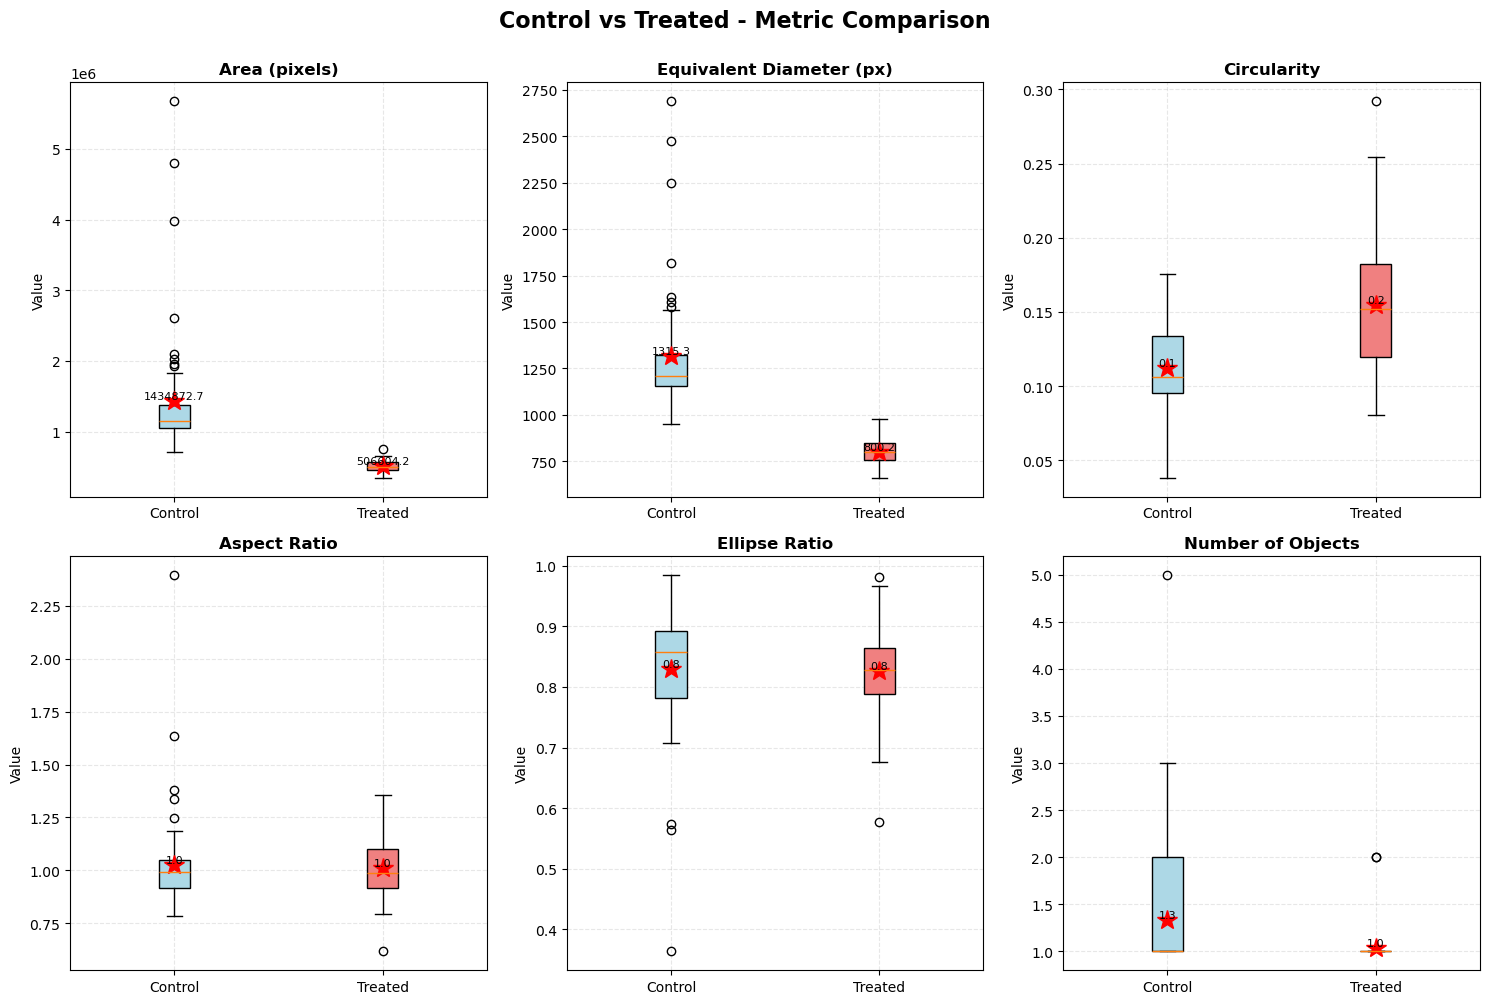

✅ Saved box plot: inference_results\summary_boxplots.png


In [65]:
if all_results and len(df['group'].unique()) > 1:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    metrics_to_plot = [
        ('area_pixels', 'Area (pixels)'),
        ('equivalent_diameter', 'Equivalent Diameter (px)'),
        ('circularity', 'Circularity'),
        ('aspect_ratio', 'Aspect Ratio'),
        ('ellipse_ratio', 'Ellipse Ratio'),
        ('num_objects', 'Number of Objects')
    ]
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[idx]
        data = [df[df['group'] == group][metric].values for group in ['Control', 'Treated']]
        
        # Box plot
        bp = ax.boxplot(data, labels=['Control', 'Treated'], patch_artist=True)
        
        # Color the boxes
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add mean markers
        for i, d in enumerate(data):
            mean_val = np.mean(d)
            ax.plot(i + 1, mean_val, 'r*', markersize=15)
            ax.text(i + 1, mean_val, f'{mean_val:.1f}', 
                   ha='center', va='bottom', fontsize=8)
    
    plt.suptitle('Control vs Treated - Metric Comparison', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    plot_path = output_base / 'summary_boxplots.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved box plot: {plot_path}")
else:
    print("⚠️  Need data from both groups to create comparison plots.")

## 14. Visualization - Distributions

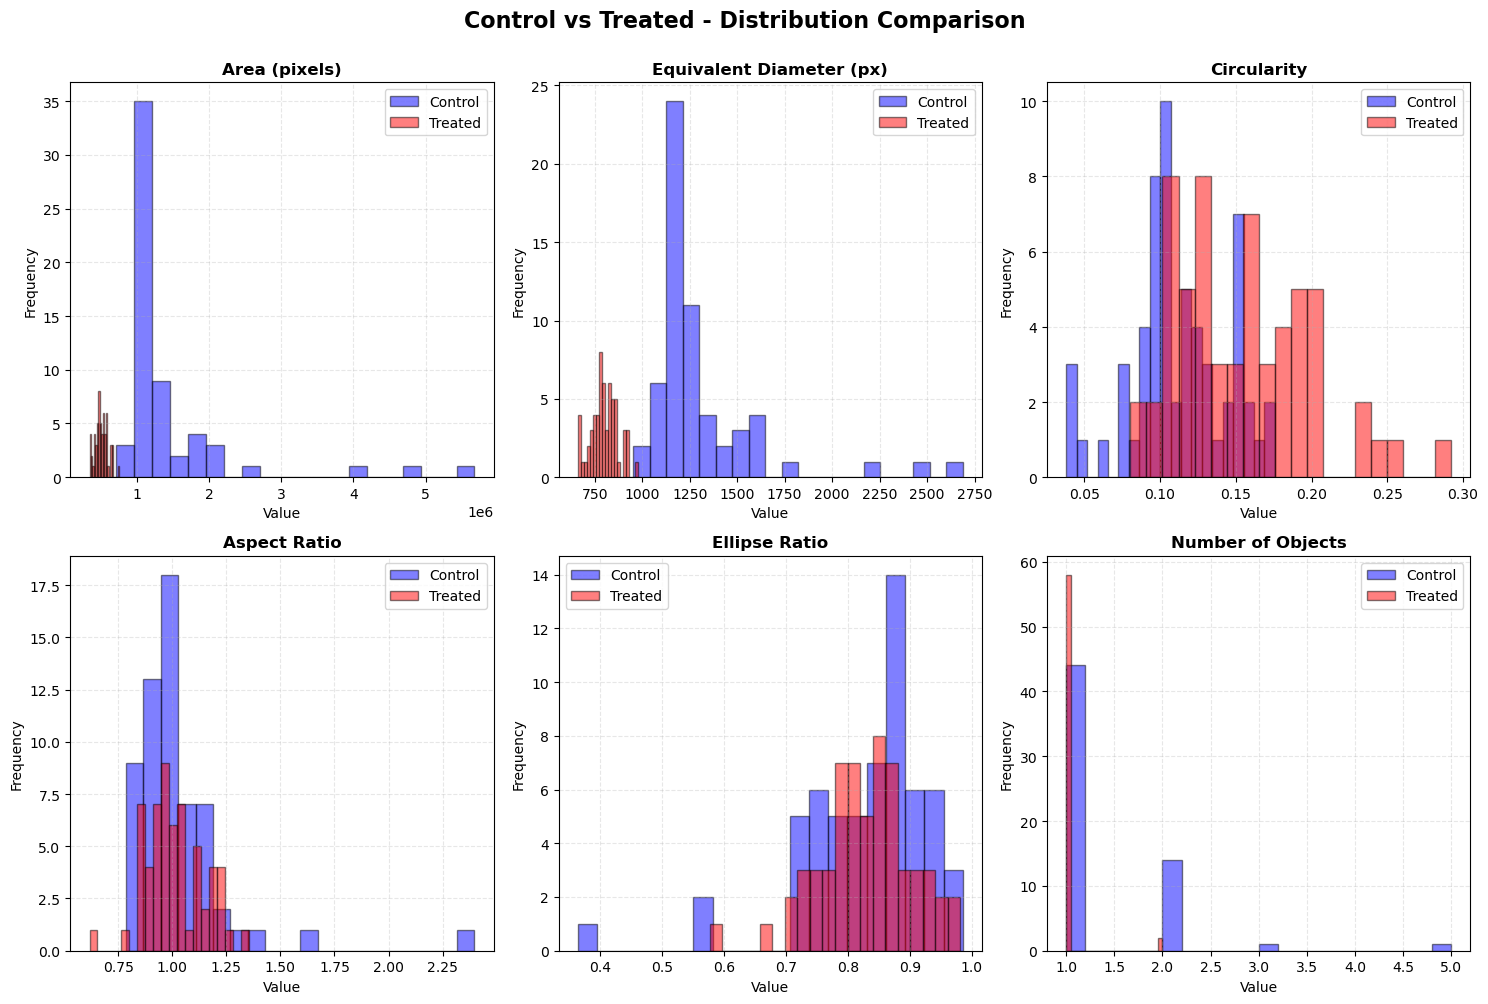

✅ Saved distribution plot: inference_results\distribution_plots.png


In [66]:
if all_results and len(df['group'].unique()) > 1:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        for group, color in [('Control', 'blue'), ('Treated', 'red')]:
            data = df[df['group'] == group][metric].values
            ax.hist(data, bins=20, alpha=0.5, label=group, color=color, edgecolor='black')
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle('Control vs Treated - Distribution Comparison', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    plot_path = output_base / 'distribution_plots.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved distribution plot: {plot_path}")
else:
    print("⚠️  Need data from both groups to create comparison plots.")

## 15. View Sample Results
Display a few sample grids to verify quality

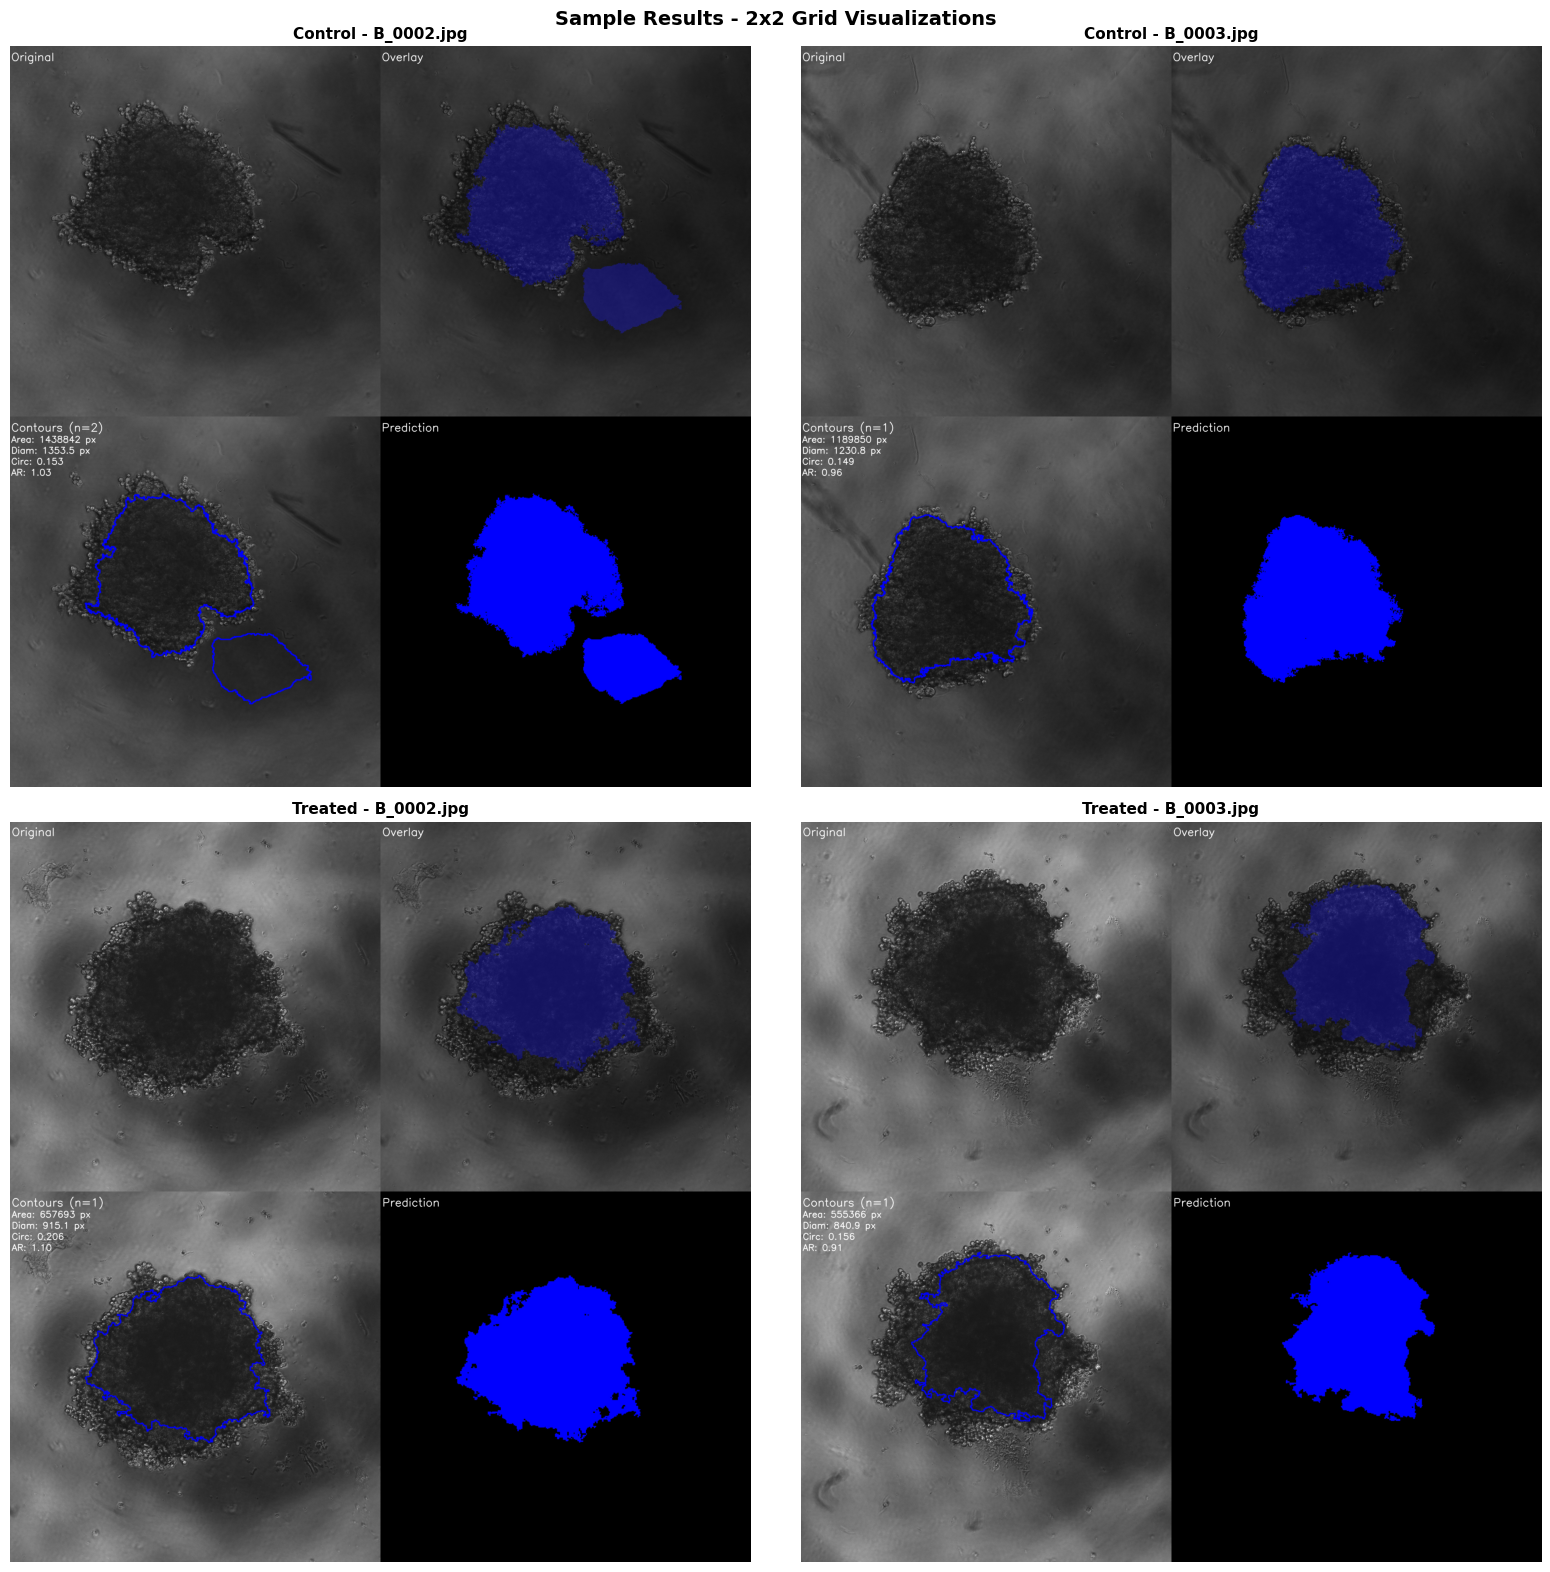

In [67]:
if all_results:
    # Display sample grids
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()
    
    # Get 4 sample images (2 from each group if possible)
    samples = []
    for group in ['Control', 'Treated']:
        group_files = sorted((output_base / 'grids' / group).glob('*.jpg'))[:2]
        if not group_files:
            group_files = sorted((output_base / 'grids' / group).glob('*.png'))[:2]
        samples.extend(group_files)
    
    for idx, img_path in enumerate(samples[:4]):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_path.parent.name} - {img_path.name}", fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(samples), 4):
        axes[idx].axis('off')
    
    plt.suptitle('Sample Results - 2x2 Grid Visualizations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No results to display.")

## 16. Final Summary
Overview of all generated outputs

In [68]:
print("\n" + "="*70)
print("INFERENCE PIPELINE COMPLETE!")
print("="*70)

if all_results:
    print(f"\n📊 Summary:")
    print(f"   Total images processed: {len(all_results)}")
    for group in ['Control', 'Treated']:
        count = len(df[df['group'] == group])
        if count > 0:
            print(f"   - {group}: {count} images")
    
    print(f"\n📁 Output directory: {output_base}")
    print(f"\n📂 Generated files:")
    print(f"   ├── grids/          - 2x2 comparison grids (⭐ Best for quick review)")
    print(f"   ├── overlays/       - Predictions overlaid on originals")
    print(f"   ├── contours/       - Contour visualizations with metrics")
    print(f"   ├── predictions/    - Colored prediction masks")
    print(f"   ├── masks/          - Binary PNG masks (0=black, 255=white)")
    print(f"   ├── segmentation_results.csv - Detailed metrics table")
    print(f"   ├── summary_boxplots.png - Statistical comparison plots")
    print(f"   └── distribution_plots.png - Distribution histograms")
    
    print(f"\n💡 Next steps:")
    print(f"   1. Check grids/ folder for visual quality assessment")
    print(f"   2. Review segmentation_results.csv for quantitative analysis")
    print(f"   3. Examine summary plots for group comparisons")
    print(f"   4. Use masks/ for further image analysis if needed")
    
    print(f"\n📏 Note: All metrics calculated on FULL-RESOLUTION masks (not 512×512)")
else:
    print(f"\n⚠️  No results were generated. Please check:")
    print(f"   - DATA_DIR path is correct")
    print(f"   - Control and/or Treated folders exist")
    print(f"   - Images are in supported formats (.jpg, .png, .jpeg)")

print(f"\n" + "="*70)


INFERENCE PIPELINE COMPLETE!

📊 Summary:
   Total images processed: 120
   - Control: 60 images
   - Treated: 60 images

📁 Output directory: inference_results

📂 Generated files:
   ├── grids/          - 2x2 comparison grids (⭐ Best for quick review)
   ├── overlays/       - Predictions overlaid on originals
   ├── contours/       - Contour visualizations with metrics
   ├── predictions/    - Colored prediction masks
   ├── masks/          - Binary PNG masks (0=black, 255=white)
   ├── segmentation_results.csv - Detailed metrics table
   ├── summary_boxplots.png - Statistical comparison plots
   └── distribution_plots.png - Distribution histograms

💡 Next steps:
   1. Check grids/ folder for visual quality assessment
   2. Review segmentation_results.csv for quantitative analysis
   3. Examine summary plots for group comparisons
   4. Use masks/ for further image analysis if needed

📏 Note: All metrics calculated on FULL-RESOLUTION masks (not 512×512)

